# Python Programming - Final Project
# Dataset Analysis Report

**Student name:** *Afonso Gonçalves*  
**Date:** *05/06/2026*  
**Dataset:** Video Game Sales (VGChartz / Kaggle, 1980-2020)

---

## Instructions

Complete every section below. **Do not delete any section header.**

Requirements:
- The notebook must **run top-to-bottom without errors** before submission
- Minimum **5 visualisations** using at least **3 different chart types**
- Each chart must be followed by a **written interpretation** in a markdown cell
- Minimum **3 business insights** in the Key Insights section
- All markdown text cells must be filled in (no placeholder text left)

**Recommended dataset sources:**
- [Kaggle Datasets](https://www.kaggle.com/datasets)
- [dados.gov.pt](https://dados.gov.pt) - Portuguese open data
- [data.europa.eu](https://data.europa.eu) - EU open data
- [ourworldindata.org](https://ourworldindata.org) - global datasets with context
- [INE Portugal](https://www.ine.pt)

**Minimum dataset size:** 500 rows, 6+ columns (mix of numeric and categorical)

---

## 1. Introduction

**What is this dataset?**  
This dataset contains historical sales figures for 16,598 video games released between 1980 and 2020 across 31 platforms. Each row represents a single game on a single platform, described by its title, platform, release year, genre and publisher, together with the number of units sold (in millions of copies) broken down by region: North America (`NA_Sales`), Europe (`EU_Sales`), Japan (`JP_Sales`), the rest of the world (`Other_Sales`) and the worldwide total (`Global_Sales`). The data originates from VGChartz, a service that estimates physical game sales by aggregating retail and shipment data, and was compiled and published as an open dataset on Kaggle (originally scraped in 2016). It mixes categorical variables (Platform, Genre, Publisher) with numeric ones (Year and the five sales columns), comfortably exceeding the minimum of 500 rows and 6 columns.

**What business or organisational context does it represent?**  
The data sits in the video game publishing and retail industry, which is a market worth well over US$150 billion globally. From the perspective of a publisher (such as Nintendo or Electronic Arts) or a platform holder (Sony, Microsoft, Nintendo), figures like these drive concrete decisions: which **genres** to greenlight, which **regions** to prioritise for a launch, which **platforms** are worth supporting, and how the market has shifted across **console generations**. Because the sales are split by region, the dataset is especially useful for understanding *where* different kinds of games succeed. This is a question that directly impacts marketing spending, localisation and distribution managerial choices.

**Why did you choose it?**  
I chose this dataset because I am personally interested in the video game industry and was curious whether the things I assume as a player hold up in the data. Actually with the dataset it is harder to get my point of view, since Europe is such a smaller player in video game market compared to NA or Asia (specifically Japan).
Also the dataset is large and slightly messy (it has missing release years and a few odd values), which makes it a realistic test of the cleaning and exploration skills from the course rather than a tidy, pre-packaged example. This could make it richer for the assignment.

(The fact that there was video game data available for us to chose, gave me freedom to also pick something more interesting than just "normal" sales)

---
## 2. Data Loading & Exploration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()
%matplotlib inline

In [2]:
# Load the dataset (kept inside the files/ folder per the project guidelines)
df = pd.read_csv('files/vgsales.csv')

df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [3]:
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")

Shape: 16598 rows, 11 columns


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB


In [5]:
# Summary statistics for the numeric columns (sales are in MILLIONS of units sold)
df.describe().round(2)

,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16598.00,16327.00,16598.00,16598.00,16598.00,16598.00,16598.00
mean,8300.61,2006.41,0.26,0.15,0.08,0.05,0.54
std,4791.85,5.83,0.82,0.51,0.31,0.19,1.56
min,1.00,1980.00,0.00,0.00,0.00,0.00,0.01
25%,4151.25,2003.00,0.00,0.00,0.00,0.00,0.06
50%,8300.50,2007.00,0.08,0.02,0.00,0.01,0.17
75%,12449.75,2010.00,0.24,0.11,0.04,0.04,0.47
max,16600.00,2020.00,41.49,29.02,10.22,10.57,82.74


In [6]:
print("Missing values per column:")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({"missing": missing, "missing_%": missing_pct})

Missing values per column:


,missing,missing_%
Rank,0,0.00
Name,0,0.00
Platform,0,0.00
Year,271,1.63
Genre,0,0.00
Publisher,58,0.35
NA_Sales,0,0.00
EU_Sales,0,0.00
JP_Sales,0,0.00
Other_Sales,0,0.00


In [7]:
# Categorical variables and the time span
print(f"Year range: {df['Year'].min():.0f} - {df['Year'].max():.0f}")
print(f"Platforms: {df['Platform'].nunique()} | Genres: {df['Genre'].nunique()} | Publishers: {df['Publisher'].nunique()}")
print("---")
print("Top 5 genres by number of titles:")
print(df['Genre'].value_counts().head(5))
print("---")
print("Top 5 platforms by number of titles:")
print(df['Platform'].value_counts().head(5))

Year range: 1980 - 2020
Platforms: 31 | Genres: 12 | Publishers: 578
---
Top 5 genres by number of titles:
Genre
Action          3316
Sports          2346
Misc            1739
Role-Playing    1488
Shooter         1310
Name: count, dtype: int64
---
Top 5 platforms by number of titles:
Platform
DS      2163
PS2     2161
PS3     1329
Wii     1325
X360    1265
Name: count, dtype: int64


**Exploration observations:**  

The dataset loads with **16,598 rows x 11 columns** (meets the project requirements). The structure is a mix of types: four categorical/text columns (`Name`, `Platform`, `Genre`, `Publisher`), one temporal column (`Year`), and six numeric columns (`Rank` plus the five sales figures). A few things stand out:

- **Missing values are concentrated in two columns.** `Year` is missing for **271 rows (1.63%)** and `Publisher` for **58 rows (0.35%)**. Every other column is complete. 

- **`Year` is stored as a float** (e.g. `2006.0`) even though it is a calendar year. It should be converted to an integer once the missing values are removed, so it reads and plots correctly.

- **`Rank` is just a pre-sorted index.** The data already arrives ordered by `Global_Sales` descending, so `Rank` carries no independent information and will not be used in the analysis.

- **Sales are heavily right-skewed - a few blockbusters dominate.** Global sales have a mean of **0.54M** units but a median of only **0.17M**, and the maximum is **82.74M** (Wii Sports). The typical game sells modestly while a tiny number of mega-hits pull the average up. (For deeper analysis in Section 4)

- **The most recent years are sparsely recorded.** 2016 holds only **344** titles (versus roughly 600-1,400 in the years before it), and 2017 and 2020 have just **3** and **1** records respectively. Because the dataset was scraped around 2016-2017, these final years are clearly incomplete rather than evidence of a real market crash. (because of this, Chart 3 which is deliberately cut at 2015, otherwise would have a very inclined descend)

- **North America is the largest market on average** (mean 0.26M per title), ahead of Europe (0.15M) and Japan (0.08M). (for this the regional-taste angle is worth exploring)

- **The market is concentrated.** Action, Sports and Misc are the most common genres; the DS and PS2 carry the most titles; and a handful of publishers (Electronic Arts, Activision, Namco Bandai, Ubisoft, Konami) account for a large share of releases.

These observations set up three cleaning decisions for the next section: drop the rows with no release year, decide how to treat the missing publishers, and fix the `Year` data type.

---
## 3. Data Cleaning

*Document every cleaning step with a comment explaining WHY you made that decision.*

In [8]:
# Step 1: Drop rows with a missing release Year, then convert Year to integer.
# WHY: Year is a continuous axis variable used to place each game on a timeline. 
# A row with no year cannot sit on a numeric time axis and cannot take part in any time-based analysis, so it makes less sense to keep it for Chart 3. 
# As this affects only 271 rows (~1.6%) and removing them does not change any ranking or conclusion, so they were dropped.
# Year is then converted from float (2006.0) to int (2006) so it reads and plots as a proper calendar year.

n0 = len(df)
df = df.dropna(subset=['Year'])
print(f"Removed {n0 - len(df)} rows with missing Year. Remaining: {len(df)}")

df['Year'] = df['Year'].astype(int)
print(f"Year dtype is now: {df['Year'].dtype}")

Removed 271 rows with missing Year. Remaining: 16327
Year dtype is now: int64


In [9]:
# Step 2: Fill the 58 missing Publisher values with "Unknown" instead of dropping.
# WHY: unlike Year, Publisher is a categorical variable. 
# A blank can simply be bucketed as "Unknown", and the row stays fully usable everywhere else (genre, platform and regional analysis), since its sales figures are intact.
# Dropping these rows would discard valid sales data to fix a label we do not strictly need. 
# They were labelled them "Unknown" so they are explicit, and excluded "Unknown" only when ranking publishers specifically (Chart 1).

n_missing = df['Publisher'].isnull().sum()
df['Publisher'] = df['Publisher'].fillna('Unknown')
print(f"Filled {n_missing} missing Publisher values with 'Unknown'.")
print(f"Remaining missing values in dataset: {df.isnull().sum().sum()}")

Filled 36 missing Publisher values with 'Unknown'.
Remaining missing values in dataset: 0


In [10]:
# Step 3: Verify there are no exact duplicate rows, and confirm the cleaned shape.
# WHY: a good final check before analysis. 
# Note that the same game appearing on different platforms is NOT a duplicate (each platform release is a distinct product), so it was checked for fully identical rows only.

print(f"Exact duplicate rows: {df.duplicated().sum()}")
print(f"Final cleaned dataset: {df.shape[0]} rows, {df.shape[1]} columns")

df.info()

Exact duplicate rows: 0
Final cleaned dataset: 16327 rows, 11 columns
<class 'pandas.core.frame.DataFrame'>
Index: 16327 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16327 non-null  int64  
 1   Name          16327 non-null  object 
 2   Platform      16327 non-null  object 
 3   Year          16327 non-null  int64  
 4   Genre         16327 non-null  object 
 5   Publisher     16327 non-null  object 
 6   NA_Sales      16327 non-null  float64
 7   EU_Sales      16327 non-null  float64
 8   JP_Sales      16327 non-null  float64
 9   Other_Sales   16327 non-null  float64
 10  Global_Sales  16327 non-null  float64
dtypes: float64(5), int64(2), object(4)
memory usage: 1.5+ MB


**Cleaning summary:**  

- **Dropped 271 rows with a missing release `Year` (~1.6% of the data).** Year is a continuous variable used to position games on a timeline; a row with no year cannot sit on a numeric time axis or contribute to any time-based chart, so it is removed. The loss is negligible and changes no ranking or conclusion. This is the same `dropna` strategy used in the labs.

- **Converted `Year` from float to integer.** After removing the blanks, years like `2006.0` were cast to `2006` so they display and plot as proper calendar years.

- **Filled 58 missing `Publisher` values with `"Unknown"` rather than dropping them.** Unlike **Year**, **Publisher** is a categorical variable and blank can be labeled as "Unknown" while the row's sales data stays fully usable for genre, platform and regional analysis. Dropping would needlessly discard valid data. "Unknown" is excluded only when ranking publishers specifically (Chart 1).

- **Checked for duplicates: none found.** There were zero fully identical rows. The same title appearing on multiple platforms was intentionally *not* treated as a duplicate, since each platform release is a distinct product.
- **Noted but not altered:** 4 rows carry a release year beyond 2016 (the dataset's approximate scrape date). These are a known data-source quirk and are left in place; the limitation is recorded in Section 6.

The dataset is now clean: **16,327 rows x 11 columns** with **no missing values**, ready for analysis.

---
## 4. Exploratory Analysis

*At least 5 charts using at least 3 different chart types.  
Each chart must be followed by a written interpretation.*

> **Remember:** A chart without a written interpretation is not an insight.
> An insight must say what the number **means for the business or organisation**.

### Chart 1 - Top 10 Publishers by Total Global Sales

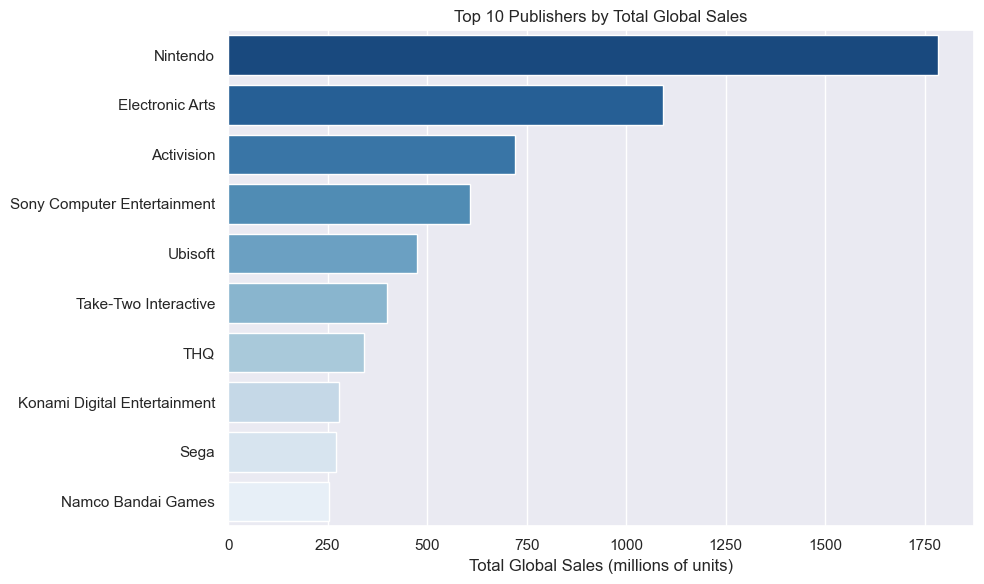

In [11]:
# Chart 1: Which publishers sell the most games worldwide?
# Excluded "Unknown" so the missing-publisher rows never appear as a fake leader.
top_pub = (
    df[df['Publisher'] != 'Unknown']
    .groupby('Publisher')['Global_Sales'].sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_pub, x='Global_Sales', y='Publisher',
            hue='Publisher', palette='Blues_r', legend=False)
plt.title('Top 10 Publishers by Total Global Sales')
plt.xlabel('Total Global Sales (millions of units)')
plt.ylabel('')
plt.tight_layout()
plt.show()

**Interpretation:**  
Nintendo is the clear market leader with roughly **1,784M** units sold worldwide during this period. This is about 63% more than Electronic Arts (~1,093M), which is in second place, followed by Activision (~721M). The market is highly concentrated at the top: a handful of publishers account for a disproportionate share of all sales. 

Nintendo's lead is especially striking given that, unlike EA or Activision, it publishes almost exclusively for its own platforms, showing a sign of how powerful first-party franchises (Mario, Pokemon, Wii Sports) are as a sales engine.

### Chart 2 - Total Global Sales by Genre

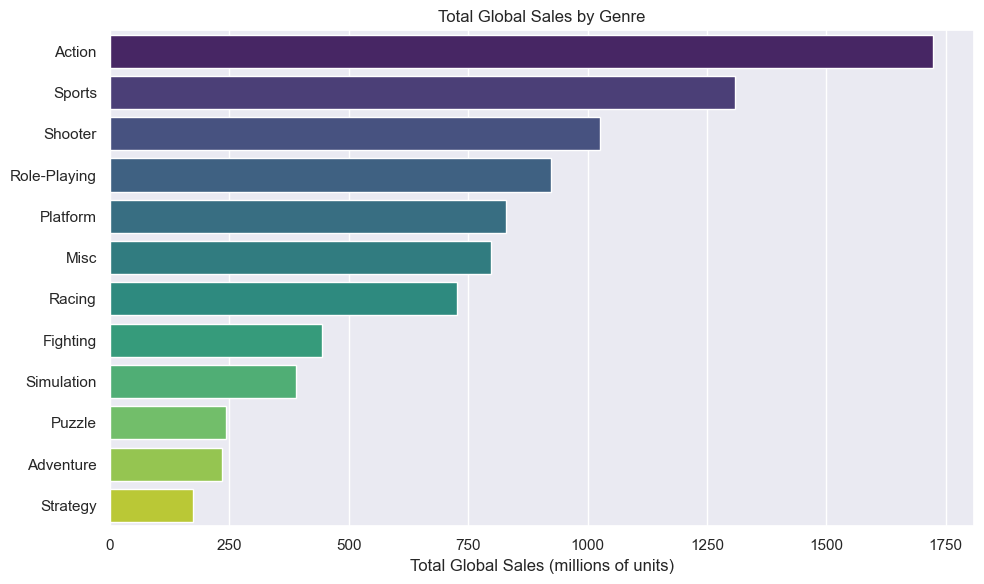

In [12]:
# Chart 2: Which genres generate the most sales overall?
genre_sales = (
    df.groupby('Genre')['Global_Sales'].sum()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(10, 6))
sns.barplot(data=genre_sales, x='Global_Sales', y='Genre',
            hue='Genre', palette='viridis', legend=False)
plt.title('Total Global Sales by Genre')
plt.xlabel('Total Global Sales (millions of units)')
plt.ylabel('')
plt.tight_layout()
plt.show()

**Interpretation:**  
Action is the highest-selling genre (~**1,723M** units), followed by Sports (~1,309M) and Shooter (~1,026M). At the other end, Strategy (~173M) and Adventure (~235M) sell roughly a tenth of what Action does. 

The pattern points to a mass-market versus niche split: broad, accessible genres dominate volume, while Strategy and Adventure serve smaller, dedicated audiences. For a publisher allocating a development budget, this suggests Action/Sports/Shooter titles offer the largest addressable market. However, the largest markets are also the most crowded, so strong demand likely comes paired with heavy competition and thinner per-title margins.

### Chart 3 - Global Sales Over Time (1980-2015)

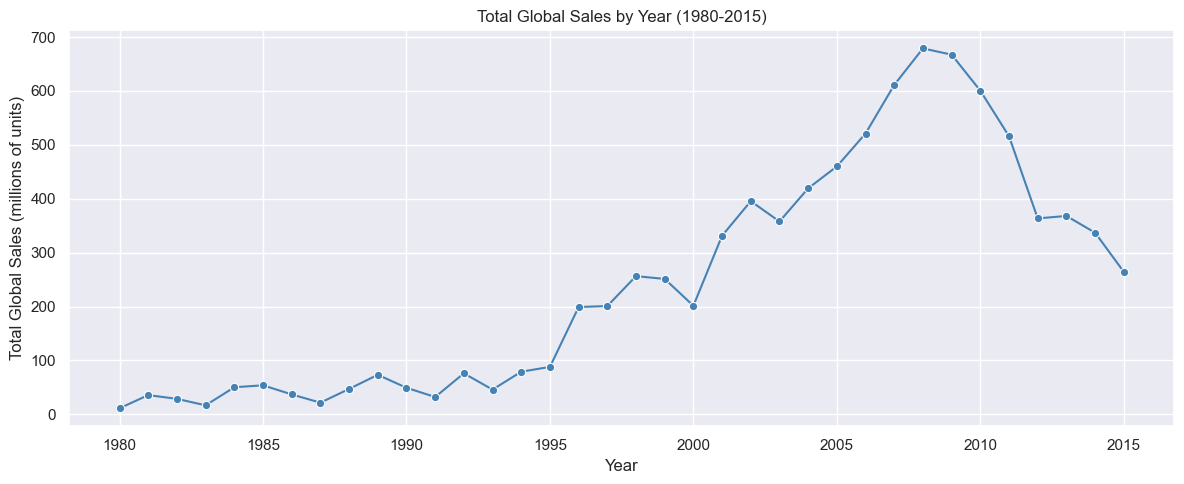

In [13]:
# Chart 3: How have total global sales changed over time?
# IMPORTANT: the series was cut at 2015. 
# The dataset was scraped around 2016-2017, so 2016 is only partially recorded and 2017/2020 are near-empty artifacts.
# Plotting them would show a false "collapse". Those rows were kept in the dataset but exclude the incomplete tail from this time-trend chart only.
sales_by_year = (
    df[df['Year'] <= 2015]
    .groupby('Year')['Global_Sales'].sum()
    .reset_index()
)

plt.figure(figsize=(12, 5))
sns.lineplot(data=sales_by_year, x='Year', y='Global_Sales',
             marker='o', color='steelblue')
plt.title('Total Global Sales by Year (1980-2015)')
plt.xlabel('Year')
plt.ylabel('Total Global Sales (millions of units)')
plt.tight_layout()
plt.show()

**Interpretation:**  
Recorded sales grew steadily from the 1980s, accelerated through the 2000s, and **peaked in 2008 at ~679M** units - the height of the Wii / DS / PS3 / Xbox 360 generation - before declining to ~264M by 2015. This decline should be read carefully. Part of it is **real**: from roughly 2010 onward the industry shifted heavily toward digital downloads and mobile, which this physical-sales dataset largely does not capture. Part of it is a **data artifact**: years near the scrape date are increasingly incomplete. 

The best conclusion is that *physical, retail-tracked* game sales peaked around 2008-2009; the chart cannot speak to total industry revenue in the digital era.

### Chart 4 - Regional Sales Share by Genre

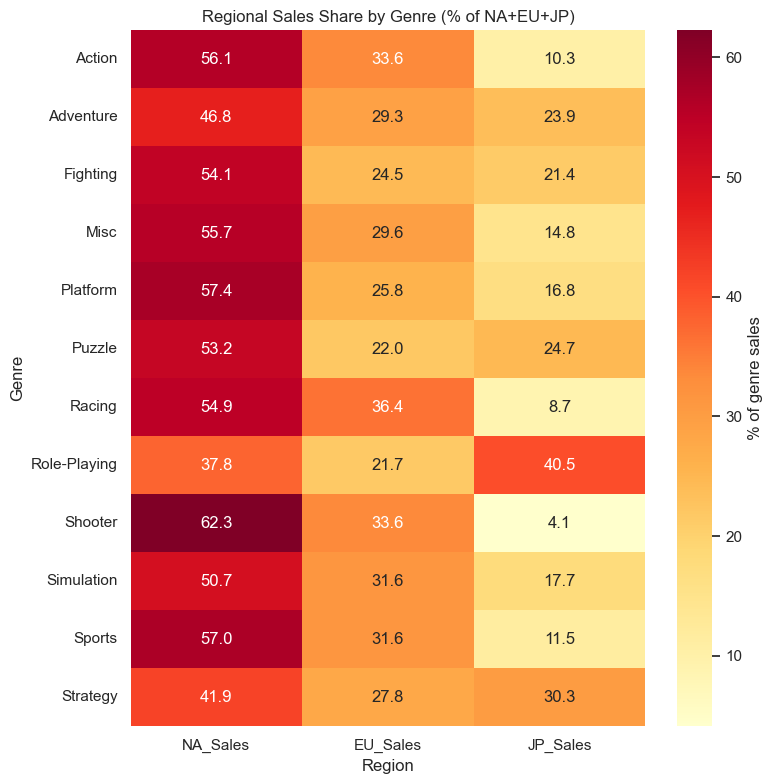

In [14]:
# Chart 4: Do different regions prefer different genres?
# Computed each genre's sales split across NA / EU / JP as a percentage, so every row sums to 100% and we compare TASTE rather than raw volume.
region_cols = ['NA_Sales', 'EU_Sales', 'JP_Sales']
genre_region = df.groupby('Genre')[region_cols].sum()
genre_share = genre_region.div(genre_region.sum(axis=1), axis=0) * 100

plt.figure(figsize=(8, 8))
sns.heatmap(genre_share, annot=True, fmt='.1f', cmap='YlOrRd',
            cbar_kws={'label': '% of genre sales'})
plt.title('Regional Sales Share by Genre (% of NA+EU+JP)')
plt.xlabel('Region')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()

**Interpretation:**  
Regional taste diverges sharply. Role-Playing games draw about **40%** of their sales from Japan (the most Japan-centric genre) whereas Shooters take only ~**4%** from Japan and over **62%** from North America. (I guess a joke could be made here...)

In short, the West buys Shooters and Japan buys RPGs. This has direct commercial implications: a publisher launching a shooter should concentrate marketing and localisation spend in North America and Europe, while an RPG cannot be considered global without a serious Japanese strategy. The genre-by-region view makes the cultural split explicit, which averages alone would hide.

### Chart 5 - North America vs Japan Sales (per game)

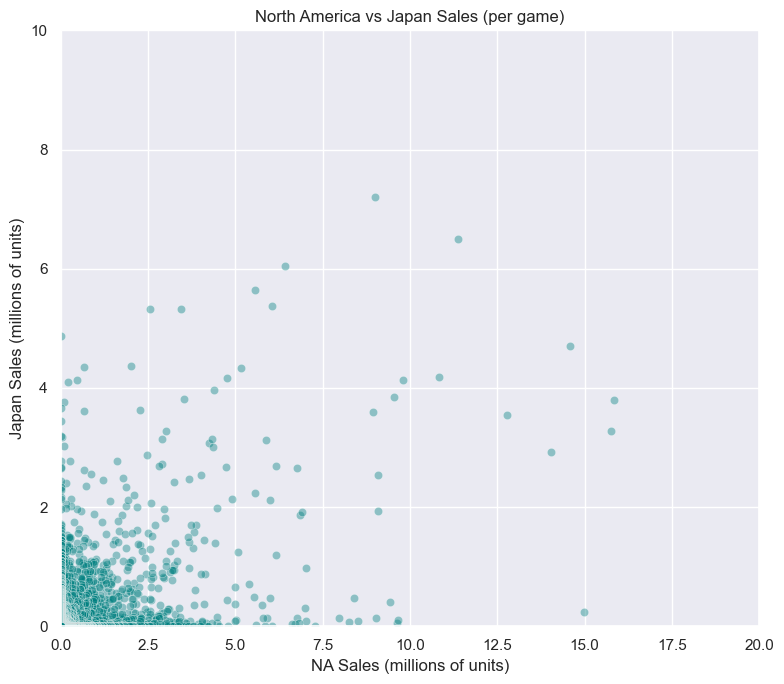

NA-EU correlation: 0.77
NA-JP correlation: 0.45


In [15]:
# Chart 5: At the individual-game level, do NA hits also succeed in Japan?
# Scatter of NA vs JP sales. Most games sell little; zoommed into the 0-20M / 0-10M range to see the bulk clearly (a few mega-hits sit off-chart).
plt.figure(figsize=(8, 7))
sns.scatterplot(data=df, x='NA_Sales', y='JP_Sales', alpha=0.4, color='teal')
plt.title('North America vs Japan Sales (per game)')
plt.xlabel('NA Sales (millions of units)')
plt.ylabel('Japan Sales (millions of units)')
plt.xlim(0, 20)
plt.ylim(0, 10)
plt.tight_layout()
plt.show()

# Correlations to quantify the relationship
print(f"NA-EU correlation: {df['NA_Sales'].corr(df['EU_Sales']):.2f}")
print(f"NA-JP correlation: {df['NA_Sales'].corr(df['JP_Sales']):.2f}")

**Interpretation:**  
The cloud of points hugs the axes rather than forming a tight diagonal: many games sell well in North America while selling almost nothing in Japan, and vice-versa. The correlation confirms it as well. NA and Japan sales correlate only **0.45**, whereas NA and Europe correlate **0.77**. North America and Europe behave like one broadly aligned Western market, while Japan is a genuinely separate one. 

For a publisher, this means a North American hit is a reasonable predictor of European success but a poor predictor of Japanese success. Japan definitely needs to be evaluated and marketed to on its own terms.

---
## 5. Key Insights

*Write 3-5 bullet points for a non-technical manager.*  
*Each insight must (1) state what you found and (2) explain what it means for the organisation.*

**Example of a weak finding:** "Revenue in Q4 is 42,000."  
**Example of a strong insight:** "Q4 generates 38% of annual revenue, almost double any other quarter, suggesting that marketing and inventory investment should be concentrated in the Oct-Dec window."

---

- **Insight 1 - Nintendo is the dominant force, powered by its own franchises.** Nintendo has sold roughly **1,784M** units worldwide, about 63% more than the next publisher (Electronic Arts), despite publishing almost exclusively for its own consoles. *What it means:* strong first-party intellectual property (Mario, Pokemon, Wii Sports) is the single most powerful sales engine in this market, which means owning both the platform and the hit franchises beats a multi-platform catalogue.

- **Insight 2 - Japan is a separate market and must be treated as one.** North American and European sales move together (correlation **0.77**), but North America and Japan barely track each other (correlation **0.45**). At the genre level, Role-Playing games earn ~**40%** of their sales in Japan while Shooters earn only ~**4%** there and over **62%** in North America. *What it means:* a Western success is a good predictor of European performance but a poor predictor of Japanese performance. Marketing, localisation and even greenlighting decisions for Japan should be made on their own terms, not extrapolated from the West.

- **Insight 3 - Sales are concentrated in a few mass-market genres.** Action, Sports and Shooter together dominate global volume (Action alone ~**1,723M** units), while Strategy (~173M) and Adventure (~235M) sell roughly a tenth as much. *What it means:* for maximising unit volume, development budget is best weighted toward the broad-appeal genres. Strategy and Adventure are niche plays that should be justified by margin or strategic value rather than expected scale.

- **Insight 4 - Physical game sales peaked around 2008.** Recorded global sales climbed to ~**679M** units in 2008 and then declined. *What it means:* the retail, disc-based model matured over a decade ago; the industry's growth since has moved into digital and mobile channels this dataset does not capture. Any forward-looking decision based on these numbers must account for that structural shift rather than reading the post-2008 decline as a shrinking industry.

---
## 6. Conclusions & Limitations

**What would you investigate next?**  
With more data, the most valuable next step would be to join this dataset with **digital and mobile sales** and with **revenue/price** information, so the analysis could move from *units sold* to *money earned* and capture the modern market this data misses. I would also bring in **critic and user review scores** to test whether quality predicts sales, and analyse **platform life-cycles**, how a console's sales rise and fall from launch to retirement, to inform launch-window timing.

**What does this data NOT tell you?**  
Several important things. 
- It measures **units, not revenue or profit**, so a 5M-unit budget title and a 5M-unit premium title look identical here. 
- It is built from **VGChartz estimates of physical sales**, so digital downloads, mobile and free-to-play games are largely **excluded**, and the figures are approximations rather than audited accounts. 
- Recent years (2016 onward) are **incomplete**, which is why the time-trend was cut at 2015. 
- There is **no information on marketing spend, development cost, player demographics or pricing**, so the dataset can describe *what* sold but rarely *why*. Stronger conclusions would need financial and qualitative data alongside it.

**What did you learn from this project?**  
First of all, I have been a gamer most of my life. I am 25, so I did have a lot of digital copies, but I still prefer them, and I still buy them, we possible. It was not surprising, but I was not expecting the peak of physical copies sold being in the late 00's. It also confirmed the big differences between Japan's culture and western one, and I would even enjoy understanding how culture impacts gaming tastes.

Outside the scope of the data, it help me better understand and work with python for data analysis, having to plot diffenrent grphs but also to clean the data.